In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
# Define the positive and negative classes

#True value is +1
positive_points = np.array([
    (-2,3),(0,1),(2,-1)
])

negative_points = np.array([
    (-2,1),(0,-1),(2,-3)
])

In [3]:
positive_points

array([[-2,  3],
       [ 0,  1],
       [ 2, -1]])

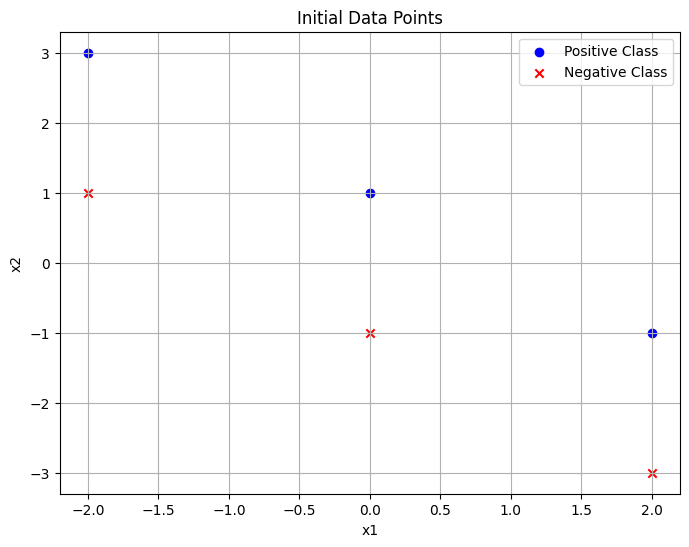

In [4]:
# Plot initial data points

plt.figure(figsize=(8,6))
plt.scatter(positive_points[:,0],positive_points[:,1],color='blue',marker='o',label='Positive Class')
plt.scatter(negative_points[:,0],negative_points[:,1],color='red',marker='x',label='Negative Class')
plt.legend(loc='best')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Initial Data Points')
plt.grid(True)

In [5]:
# Combine all points and labels
x = np.vstack((positive_points, negative_points))
y = np.array([1]*len(positive_points) + [-1]*len(negative_points))


In [6]:
y

array([ 1,  1,  1, -1, -1, -1])

In [7]:
# Perceptron algorithm
def perceptron(x,y,steps=10):
    theta = np.zeros(x.shape[1])
    theta0 = 0
    for t in range(steps):
        for i,xi in enumerate(x):
            if y[i] * (np.dot(xi,theta) + theta0) <=0:
                theta += y[i]*xi
                theta0 += y[i]
                break
        
        # Plot after each iteration
        plot_decision_boundary(theta,theta0,t+1)
    return theta,theta0

In [8]:
def plot_decision_boundary(theta,theta0,iteration):
    plt.figure(figsize=(8,6))
    plt.scatter(positive_points[:,0],positive_points[:,1],color='blue',label='Positive Class')
    plt.scatter(negative_points[:,0],negative_points[:,1],color='red',label='Negative Class')

    #plot decision boundary
    x_values = np.linspace(-3,3,2)
    # check for theta[1] to avoid division by zero in case of vertical line

    if theta[1] !=0:
        y_values = -(theta[0] *x_values + theta0) / theta[1]
        plt.plot(x_values,y_values,label=f'Iteration {iteration}')
    
    else:
        #plot vertical line
        x_val = -theta0 / theta[0]
        plt.axvline(x=x_val,label=f'Iteration{iteration}')
    
    plt.xlim(-3,3)
    plt.ylim(-4,4)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Decision Bounary at Iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.show()

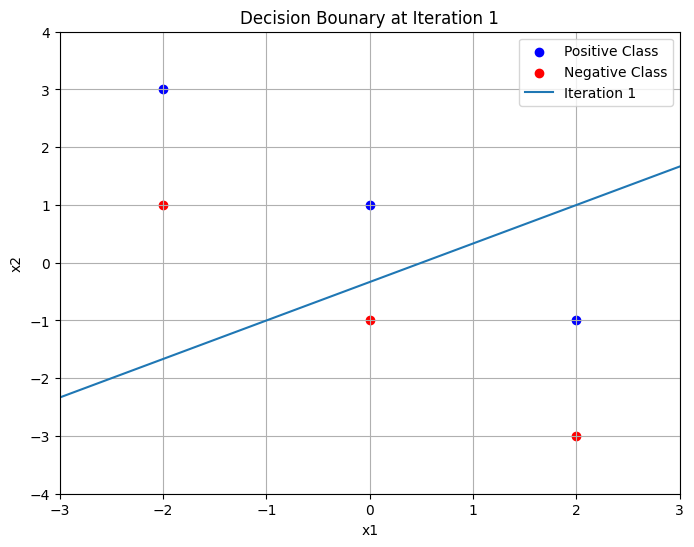

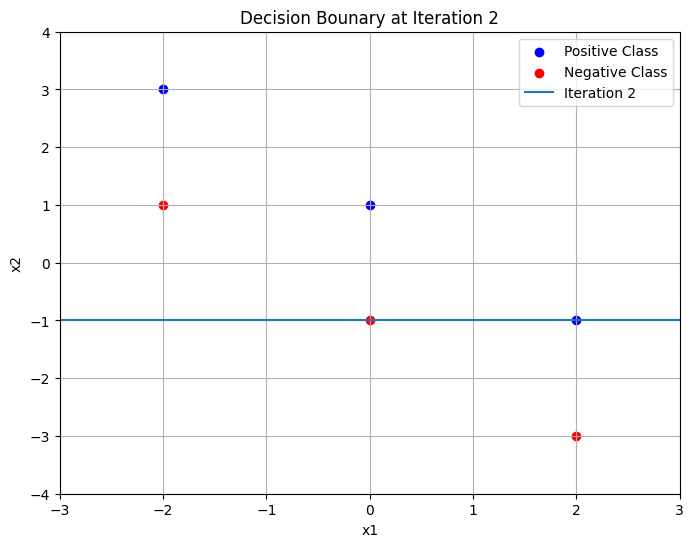

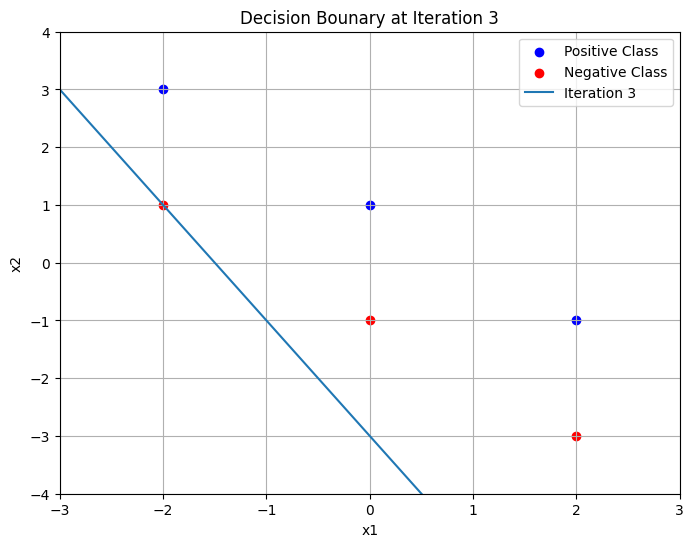

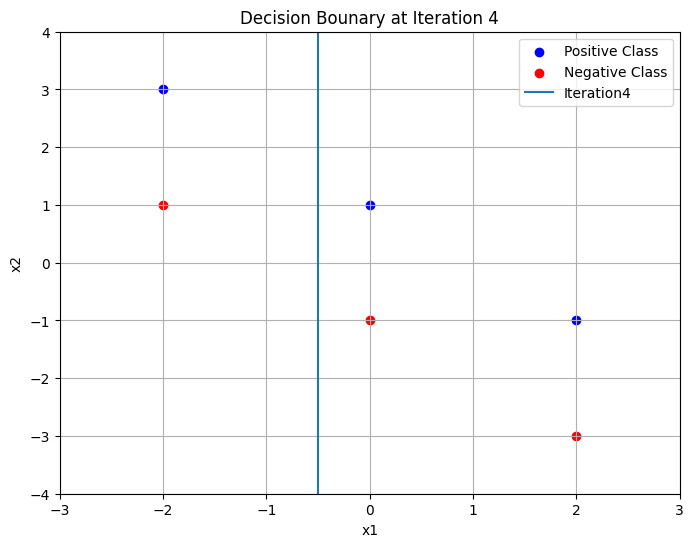

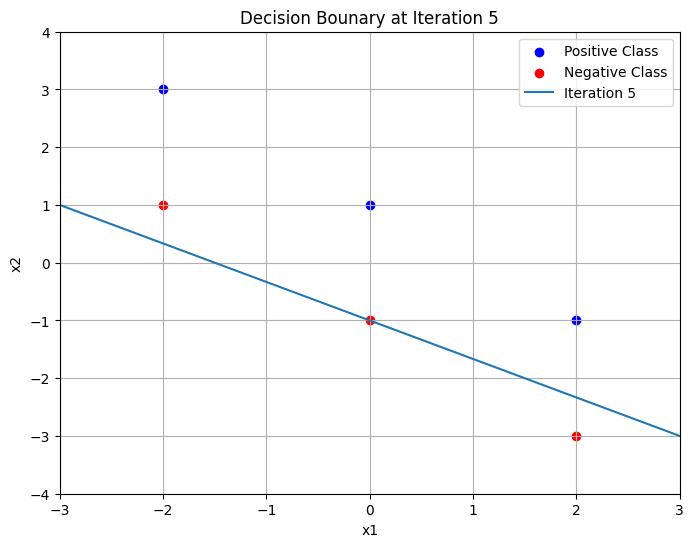

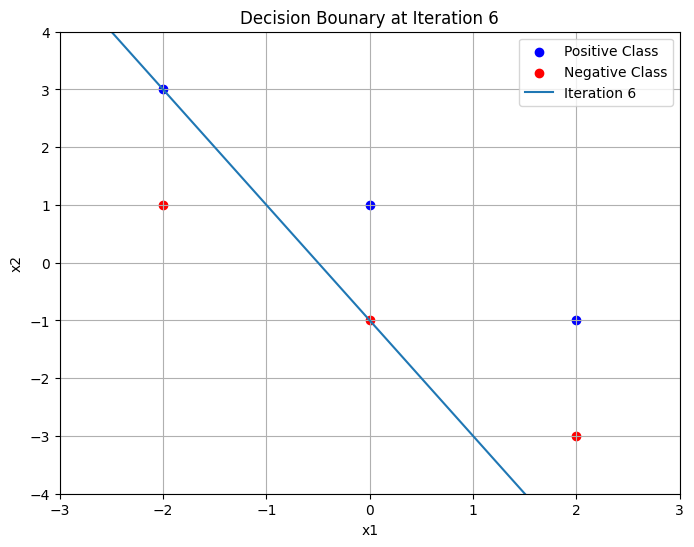

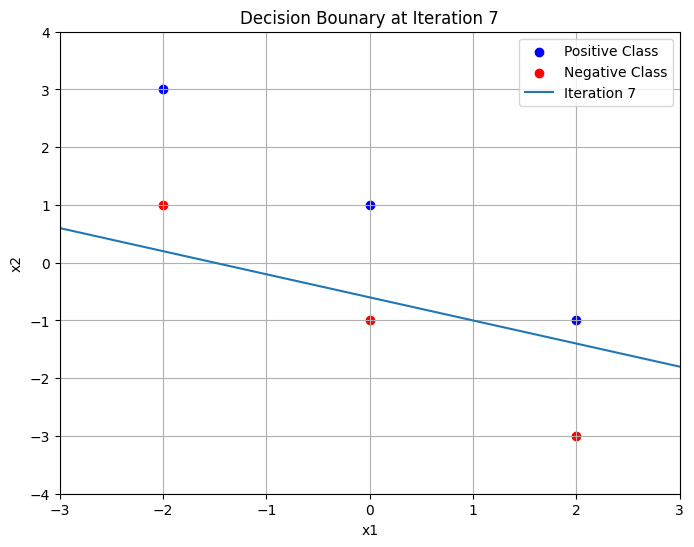

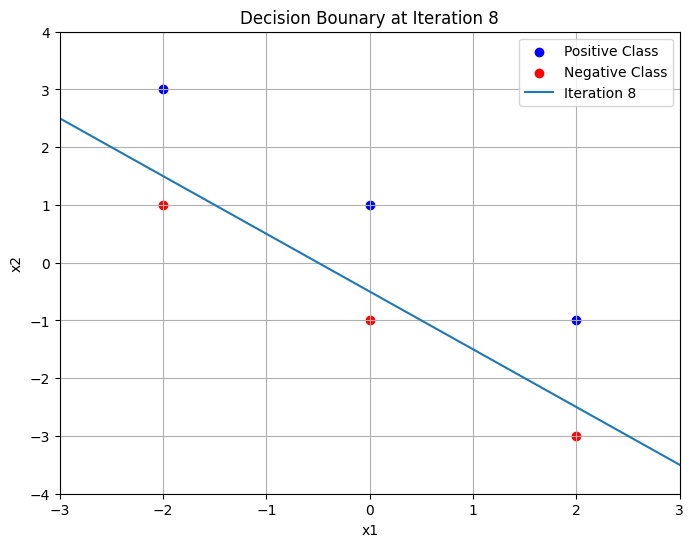

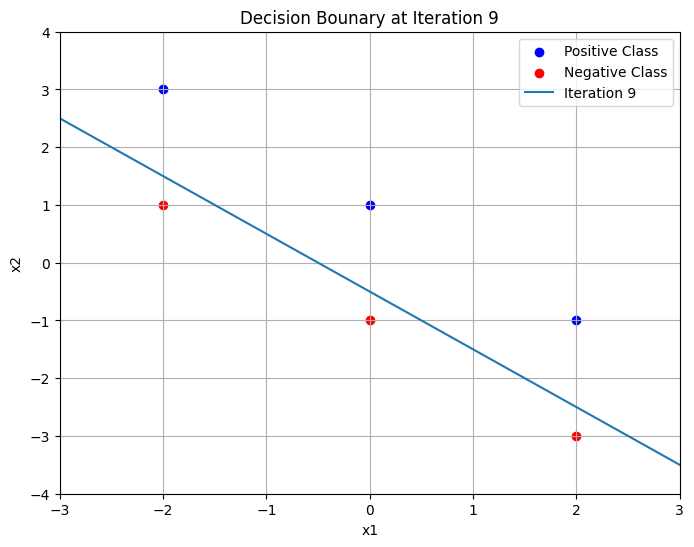

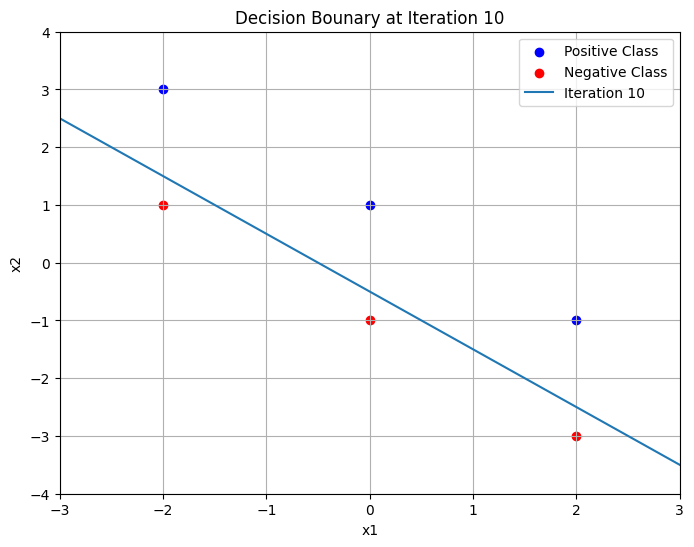

In [9]:
theta_final,theta0_final = perceptron(x,y,10)